# 2.1 Tuples and HTuples

The Tuple and HTuple concepts serve as foundational data structures throughout this work.

**Definition 2.1.** A Tuple($T$) is a finite, ordered list of elements selected from a set $T$.

For an $X = (X_0, X_1, \ldots, X_{n-1}) \in \text{Tuple}(X)$, we define the operations:

- **Rank**: $\text{rank}(X)$. The tuple length $n$.
- **Access**: $X_i$. The $i$th element of the Tuple $X$ for $0 \le i < \text{rank}(X)$.

Where a Tuple($T$) is a flat collection of elements, an HTuple($T$) is a "hierarchical tuple of $T$s".

**Definition 2.2.** An HTuple($T$) is either an element of set $T$ or a Tuple(HTuple($T$)). For an $X \in \text{HTuple}(X)$ we define the operations:

- **Rank**: $\text{rank}(X)$. If $X \in \text{Tuple}$, then the tuple length, else 1.
- **Access**: $X_i$. The $i$th element of an HTuple $X$ for $0 \le i < \text{rank}(X)$.
- **Depth**: $\text{depth}(X)$. If $X \in \text{Tuple}$, then $1 + \max(\text{depth}(X_0), \text{depth}(X_1), \ldots)$, else 0.

In [1]:
from tensor_layouts import Layout, size, rank, depth, mode
from tensor_layouts.viz import draw_layout

For instance,

$$31 \qquad (16, 32) \qquad (3, -8, 7) \qquad (2, (4, 1), -1) \qquad ((4, 6), (3, (2, 2), 8))$$

are all instances of HTuple($\mathbb{Z}$).

In CuTe, shapes (which are HTuples of positive integers) are represented directly as nested Python tuples. We can use `Layout` objects to explore these properties, since every Layout has a shape that is an HTuple.

Note: In the `tensor-layouts` library, a bare integer shape like `Layout(31, 1)` is treated as rank 0 / depth 0 (a scalar element, not a 1-tuple). To get rank 1, wrap it as `Layout((31,), (1,))`.

In [2]:
# A scalar integer: rank 0, depth 0 in the library
L_scalar = Layout(31, 1)
print(f"Layout: {L_scalar}")
print(f"  rank  = {rank(L_scalar)}")
print(f"  depth = {depth(L_scalar)}")
print()

# A flat tuple (16, 32): rank 2, depth 1
L_flat = Layout((16, 32), (1, 16))
print(f"Layout: {L_flat}")
print(f"  rank  = {rank(L_flat)}")
print(f"  depth = {depth(L_flat)}")
print()

# A flat triple (3, 8, 7): rank 3, depth 1
L_triple = Layout((3, 8, 7), (1, 3, 24))
print(f"Layout: {L_triple}")
print(f"  rank  = {rank(L_triple)}")
print(f"  depth = {depth(L_triple)}")
print()

# A hierarchical tuple (2, (4, 1)): rank 2, depth 2
# Using positive integers for a valid layout shape
L_nested = Layout((2, (4, 1)), (1, (2, 0)))
print(f"Layout: {L_nested}")
print(f"  rank  = {rank(L_nested)}")
print(f"  depth = {depth(L_nested)}")
print()

# A deeply nested tuple ((4, 6), (3, (2, 2), 8)): rank 2, depth 2+
L_deep = Layout(((4, 6), (3, (2, 2), 8)), ((1, 4), (24, (72, 144), 288)))
print(f"Layout: {L_deep}")
print(f"  rank  = {rank(L_deep)}")
print(f"  depth = {depth(L_deep)}")

Layout: 31 : 1
  rank  = 0
  depth = 0

Layout: (16, 32) : (1, 16)
  rank  = 2
  depth = 1

Layout: (3, 8, 7) : (1, 3, 24)
  rank  = 3
  depth = 1

Layout: (2, (4, 1)) : (1, (2, 0))
  rank  = 2
  depth = 2

Layout: ((4, 6), (3, (2, 2), 8)) : ((1, 4), (24, (72, 144), 288))
  rank  = 2
  depth = 3


We can access individual modes of an HTuple using `mode`. This corresponds to the $X_i$ access operation.

In [3]:
# Access individual modes
print(f"L_flat = {L_flat}")
print(f"  mode 0: {mode(L_flat, 0)}")
print(f"  mode 1: {mode(L_flat, 1)}")
print()

print(f"L_nested = {L_nested}")
print(f"  mode 0: {mode(L_nested, 0)}")
print(f"  mode 1: {mode(L_nested, 1)}  (itself an HTuple)")
print()

print(f"L_deep = {L_deep}")
print(f"  mode 0: {mode(L_deep, 0)}")
print(f"  mode 1: {mode(L_deep, 1)}")

L_flat = (16, 32) : (1, 16)
  mode 0: 16 : 1
  mode 1: 32 : 16

L_nested = (2, (4, 1)) : (1, (2, 0))
  mode 0: 2 : 1
  mode 1: (4, 1) : (2, 0)  (itself an HTuple)

L_deep = ((4, 6), (3, (2, 2), 8)) : ((1, 4), (24, (72, 144), 288))
  mode 0: (4, 6) : (1, 4)
  mode 1: (3, (2, 2), 8) : (24, (72, 144), 288)


## Congruence

When reasoning with HTuples, it is useful to define a notion of congruence and weak congruence.

**Definition 2.3.** Congruence, $\sim$, is an equivalence relation on HTuples. For $P \in \text{HTuple}(P)$ and $S \in \text{HTuple}(S)$,

$$P \sim S \quad \text{iff} \quad P \in P \text{ and } S \in S, \quad \text{or} \quad P, S \in \text{Tuple and } \text{rank}(P) = \text{rank}(S) \text{ and } \forall i\; P_i \sim S_i$$

and we say that $P$ and $S$ are congruent and have the same profile.

For instance,

$$(4, 8) \sim (5, 7) \qquad \text{and} \qquad (4, (2, 4)) \sim (7, (3, 2)) \qquad \text{and} \qquad (v, ((p, 3))) \sim (0, ((0, 0)))$$

but $(4, 8)$ and $(4, (2, 4))$ are not congruent and $(4, (2, 4))$ and $(0, ((0, 0)))$ are not congruent.

In [4]:
def congruent(P, S):
    """Test if two HTuples (nested Python tuples/ints) are congruent (~).
    Two scalars are always congruent. Two tuples are congruent if they
    have the same rank and all corresponding elements are congruent."""
    if not isinstance(P, tuple) and not isinstance(S, tuple):
        return True  # both scalars
    if isinstance(P, tuple) and isinstance(S, tuple):
        return len(P) == len(S) and all(congruent(p, s) for p, s in zip(P, S))
    return False  # one scalar, one tuple

# Congruent examples
assert congruent((4, 8), (5, 7))
assert congruent((4, (2, 4)), (7, (3, 2)))
assert congruent((9, ((3, 3),)), (0, ((0, 0),)))
print("(4, 8)         ~ (5, 7)         :", congruent((4, 8), (5, 7)))
print("(4, (2, 4))    ~ (7, (3, 2))    :", congruent((4, (2, 4)), (7, (3, 2))))
print("(9, ((3, 3),)) ~ (0, ((0, 0),)) :", congruent((9, ((3, 3),)), (0, ((0, 0),))))
print()

# Not congruent
assert not congruent((4, 8), (4, (2, 4)))
assert not congruent((4, (2, 4)), (0, ((0, 0),)))
print("(4, 8)         ~ (4, (2, 4))    :", congruent((4, 8), (4, (2, 4))))
print("(4, (2, 4))    ~ (0, ((0, 0),)) :", congruent((4, (2, 4)), (0, ((0, 0),))))

(4, 8)         ~ (5, 7)         : True
(4, (2, 4))    ~ (7, (3, 2))    : True
(9, ((3, 3),)) ~ (0, ((0, 0),)) : True

(4, 8)         ~ (4, (2, 4))    : False
(4, (2, 4))    ~ (0, ((0, 0),)) : False


## Weak Congruence

Similarly, weak congruence tests that the profile of one HTuple is at least as refined as another.

**Definition 2.4.** Weak Congruence, $\lesssim$, is a partial order on HTuples. For $P \in \text{HTuple}(P)$ and $S \in \text{HTuple}(S)$,

$$P \lesssim S \quad \text{iff} \quad P \in P, \quad \text{or} \quad P, S \in \text{Tuple and } \text{rank}(P) = \text{rank}(S) \text{ and } \forall i\; P_i \lesssim S_i$$

and we say that $P$ and $S$ are weakly congruent, $P$ coarsens the profile of $S$, and $S$ refines the profile of $P$.

For instance,

$$30 \lesssim (a, b) \lesssim (v, (0, \alpha))$$

and

$$30 \lesssim (a, b, c) \lesssim ((0, 0), 0, 0)$$

but $(a, b)$ and $(a, b, c)$ are not weakly congruent and $(v, (0, \alpha))$ and $((0, 0), 0)$ are not weakly congruent.

In [5]:
def weakly_congruent(P, S):
    """Test if P ≲ S (P coarsens the profile of S).
    A scalar P is weakly congruent with anything.
    A tuple P ≲ S requires S to also be a tuple with the same rank,
    and each element P_i ≲ S_i."""
    if not isinstance(P, tuple):
        return True  # scalar coarsens anything
    if isinstance(P, tuple) and isinstance(S, tuple):
        return len(P) == len(S) and all(weakly_congruent(p, s) for p, s in zip(P, S))
    return False  # P is tuple, S is scalar => not weakly congruent

# 30 ≲ (a, b) ≲ (v, (0, α))
assert weakly_congruent(30, (1, 2))
assert weakly_congruent((1, 2), (3, (4, 5)))
assert weakly_congruent(30, (3, (4, 5)))  # transitivity
print("30          ≲ (1, 2)       :", weakly_congruent(30, (1, 2)))
print("(1, 2)      ≲ (3, (4, 5))  :", weakly_congruent((1, 2), (3, (4, 5))))
print("30          ≲ (3, (4, 5))  :", weakly_congruent(30, (3, (4, 5))))
print()

# 30 ≲ (a, b, c) ≲ ((0, 0), 0, 0)
assert weakly_congruent(30, (1, 2, 3))
assert weakly_congruent((1, 2, 3), ((4, 5), 6, 7))
print("30          ≲ (1, 2, 3)         :", weakly_congruent(30, (1, 2, 3)))
print("(1, 2, 3)   ≲ ((4, 5), 6, 7)    :", weakly_congruent((1, 2, 3), ((4, 5), 6, 7)))
print()

# Not weakly congruent
assert not weakly_congruent((1, 2), (1, 2, 3))
assert not weakly_congruent((3, (4, 5)), ((6, 7), 8))
print("(1, 2)      ≲ (1, 2, 3)    :", weakly_congruent((1, 2), (1, 2, 3)))
print("(3, (4, 5)) ≲ ((6, 7), 8)  :", weakly_congruent((3, (4, 5)), ((6, 7), 8)))

30          ≲ (1, 2)       : True
(1, 2)      ≲ (3, (4, 5))  : True
30          ≲ (3, (4, 5))  : True

30          ≲ (1, 2, 3)         : True
(1, 2, 3)   ≲ ((4, 5), 6, 7)    : True

(1, 2)      ≲ (1, 2, 3)    : False
(3, (4, 5)) ≲ ((6, 7), 8)  : False


## Layouts with Hierarchical Shapes

In CuTe, shapes are HTuples of positive integers. A `Layout` pairs a shape with a congruent stride. The hierarchy in the shape is mirrored in the stride. Let's visualize how the same set of elements can be viewed through layouts of different hierarchical structure.

In [6]:
# A flat 2D layout: shape (4, 6), stride (1, 4)
L_flat_2d = Layout((4, 6), (1, 4))
print(f"Flat 2D: {L_flat_2d}")
print(f"  rank={rank(L_flat_2d)}, depth={depth(L_flat_2d)}, size={size(L_flat_2d)}")

# Hierarchical: shape ((2, 2), (3, 2)), stride ((1, 2), (4, 12))
# Same 24 elements, but with nested structure in both modes
L_hier = Layout(((2, 2), (3, 2)), ((1, 2), (4, 12)))
print(f"\nHierarchical: {L_hier}")
print(f"  rank={rank(L_hier)}, depth={depth(L_hier)}, size={size(L_hier)}")

# Both produce the same offsets when indexed with 1D coordinates
assert all(L_flat_2d(i) == L_hier(i) for i in range(24))
print("\nBoth layouts agree on all 1D-indexed offsets.")

Flat 2D: (4, 6) : (1, 4)
  rank=2, depth=1, size=24

Hierarchical: ((2, 2), (3, 2)) : ((1, 2), (4, 12))
  rank=2, depth=2, size=24

Both layouts agree on all 1D-indexed offsets.


Flat 2D layout (4, 6):(1, 4)


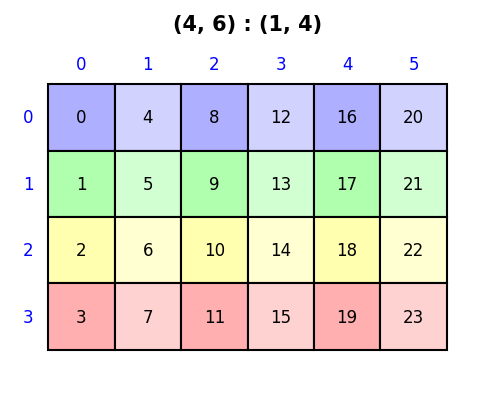

In [7]:
# Visualize the flat layout
print("Flat 2D layout (4, 6):(1, 4)")
draw_layout(L_flat_2d, colorize=True)

Hierarchical layout ((2,2), (3,2)):((1,2), (4,12))


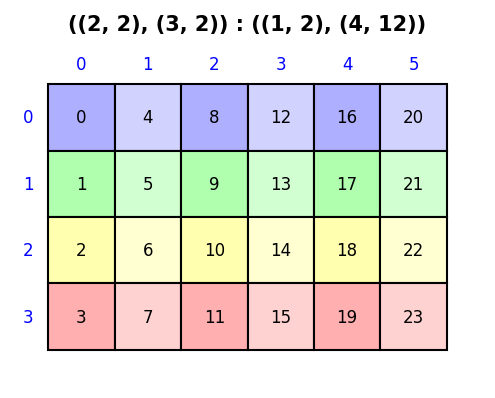

In [8]:
# Visualize the hierarchical layout
print("Hierarchical layout ((2,2), (3,2)):((1,2), (4,12))")
draw_layout(L_hier, colorize=True)